<a href="https://colab.research.google.com/github/kiransree2002/Assessment/blob/main/Model/PipelineSkeleton.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Github Commands


### <u><i>Clone the repository (once)</u></i>
`git clone https://github.com/Aravindr017/Election_Dataset_Portugal-Regression.git`

### <u><i>Enter the project</u></i>
`cd Election_Dataset_Portugal-Regression`

### <u><i>Create your branch (once)</u></i>
`git checkout -b <branch-name>`

### <u><i>Before starting new work</u></i>
`git checkout main`<br>
`git pull origin main`<br>
`git checkout <branch-name>`<br>
`git merge main`<br>

### <u><i>After making changes</u></i>
`git status`<br>
`git add .`<br>
`git commit -m "Describe your changes"`<br>

### <u><i>Upload your branch</u></i>
`git push --set-upstream origin <branch-name>`   # first push <br>
`git push`                                       # later pushes

# Importing Libraries

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# basic python libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import OneHotEncoder

# Model building
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
# cross validation
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV, RandomizedSearchCV, train_test_split

# bagging model
from sklearn.ensemble import BaggingRegressor, AdaBoostRegressor

from sklearn.ensemble import RandomForestRegressor

# metrices

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [6]:
filepath = '/content/drive/MyDrive/ElectionData (1).csv'
df_election = pd.read_csv(filepath)
df_election.head(2)

,TimeElapsed,time,territoryName,totalMandates,availableMandates,numParishes,numParishesApproved,blankVotes,blankVotesPercentage,nullVotes,...,pre.votersPercentage,pre.subscribedVoters,pre.totalVoters,Party,Mandates,Percentage,validVotesPercentage,Votes,Hondt,FinalMandates
0,0,2019-10-06 20:10:02,Território Nacional,0,226,3092,1081,9652,2.5,8874,...,52.66,813743,428546,PS,0,38.29,40.22,147993,94,106
1,0,2019-10-06 20:10:02,Território Nacional,0,226,3092,1081,9652,2.5,8874,...,52.66,813743,428546,PPD/PSD,0,33.28,34.95,128624,81,77


# EDA (Explodatory Data Analysis)

In [7]:
df_election.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21643 entries, 0 to 21642
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   TimeElapsed               21643 non-null  int64  
 1   time                      21643 non-null  object 
 2   territoryName             21643 non-null  object 
 3   totalMandates             21643 non-null  int64  
 4   availableMandates         21643 non-null  int64  
 5   numParishes               21643 non-null  int64  
 6   numParishesApproved       21643 non-null  int64  
 7   blankVotes                21643 non-null  int64  
 8   blankVotesPercentage      21643 non-null  float64
 9   nullVotes                 21643 non-null  int64  
 10  nullVotesPercentage       21643 non-null  float64
 11  votersPercentage          21643 non-null  float64
 12  subscribedVoters          21643 non-null  int64  
 13  totalVoters               21643 non-null  int64  
 14  pre.bl

In [8]:
df_election.shape

(21643, 28)

In [9]:
df_election.describe()

,TimeElapsed,totalMandates,availableMandates,numParishes,numParishesApproved,blankVotes,blankVotesPercentage,nullVotes,nullVotesPercentage,votersPercentage,...,pre.nullVotesPercentage,pre.votersPercentage,pre.subscribedVoters,pre.totalVoters,Mandates,Percentage,validVotesPercentage,Votes,Hondt,FinalMandates
count,21643.000000,21643.000000,21643.000000,21643.000000,21643.000000,21643.000000,21643.000000,21643.000000,21643.000000,21643.000000,...,21643.000000,21643.000000,2.164300e+04,2.164300e+04,21643.000000,21643.000000,21643.000000,2.164300e+04,21643.000000,21643.000000
mean,133.146052,11.544795,11.499284,309.956013,261.090237,8875.066673,2.621629,6148.068752,1.961471,51.983722,...,1.777442,54.549372,6.378503e+05,3.594932e+05,0.565495,4.968484,5.207232,1.585209e+04,1.126138,1.126138
std,77.651193,31.314567,31.738783,659.055911,583.377428,21484.874088,0.795289,14735.469269,0.375250,4.854380,...,0.388798,4.964948,1.544418e+06,8.763729e+05,4.421804,10.379967,10.881108,9.310605e+04,6.293552,6.872644
min,0.000000,0.000000,0.000000,54.000000,3.000000,19.000000,0.530000,39.000000,1.340000,35.980000,...,1.140000,40.870000,6.383000e+03,3.215000e+03,0.000000,0.020000,0.020000,1.000000e+00,0.000000,0.000000
25%,65.000000,1.000000,0.000000,75.000000,67.000000,1188.000000,2.230000,1094.000000,1.720000,50.290000,...,1.520000,51.210000,1.289260e+05,6.964400e+04,0.000000,0.220000,0.230000,2.360000e+02,0.000000,0.000000
50%,135.000000,4.000000,3.000000,147.000000,120.000000,2998.000000,2.640000,2232.000000,1.870000,53.130000,...,1.690000,56.260000,2.284970e+05,1.102730e+05,0.000000,0.620000,0.650000,7.900000e+02,0.000000,0.000000
75%,200.000000,9.000000,9.000000,242.000000,208.000000,6889.000000,2.980000,4121.000000,2.230000,54.550000,...,1.970000,58.220000,3.933140e+05,2.276200e+05,0.000000,3.010000,3.160000,4.510000e+03,0.000000,0.000000
max,265.000000,226.000000,226.000000,3092.000000,3092.000000,129599.000000,5.460000,88539.000000,3.350000,59.870000,...,3.120000,62.580000,9.439701e+06,5.380451e+06,106.000000,49.110000,51.420000,1.866407e+06,94.000000,106.000000


In [10]:
df_election.isnull().sum()

,0
TimeElapsed,0
time,0
territoryName,0
totalMandates,0
availableMandates,0
numParishes,0
numParishesApproved,0
blankVotes,0
blankVotesPercentage,0
nullVotes,0


In [11]:
df_election.duplicated().sum()

np.int64(0)

In [12]:
num_cols = []
cat_cols = []

In [13]:
num_cols = df_election.select_dtypes(include = ['int','float']).columns
num_cols

Index(['TimeElapsed', 'totalMandates', 'availableMandates', 'numParishes',
       'numParishesApproved', 'blankVotes', 'blankVotesPercentage',
       'nullVotes', 'nullVotesPercentage', 'votersPercentage',
       'subscribedVoters', 'totalVoters', 'pre.blankVotes',
       'pre.blankVotesPercentage', 'pre.nullVotes', 'pre.nullVotesPercentage',
       'pre.votersPercentage', 'pre.subscribedVoters', 'pre.totalVoters',
       'Mandates', 'Percentage', 'validVotesPercentage', 'Votes', 'Hondt',
       'FinalMandates'],
      dtype='object')

In [14]:
cat_cols = df_election.select_dtypes(['object']).columns
cat_cols

Index(['time', 'territoryName', 'Party'], dtype='object')

## Data Visualization - Plots

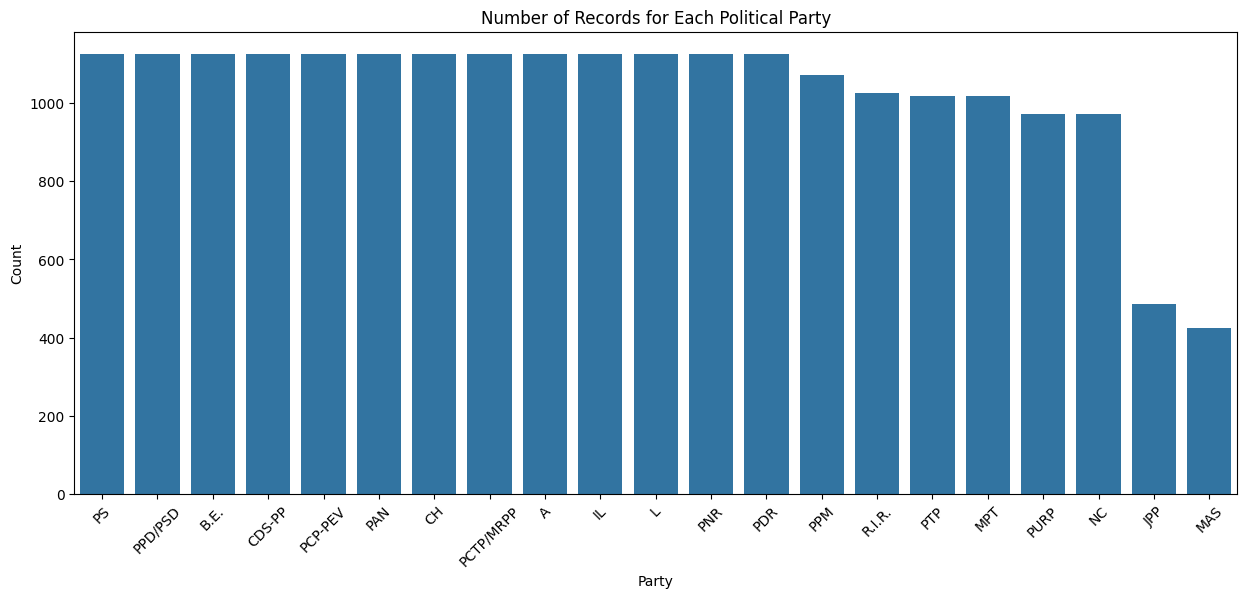

In [15]:

plt.figure(figsize=(15,6))
sns.countplot(data=df_election, x='Party', order=df_election['Party'].value_counts().index)

plt.xticks(rotation=45)   # the x label rotated 45 degree
plt.title("Number of Records for Each Political Party")
plt.xlabel("Party")
plt.ylabel("Count")
plt.show()

### Histograms

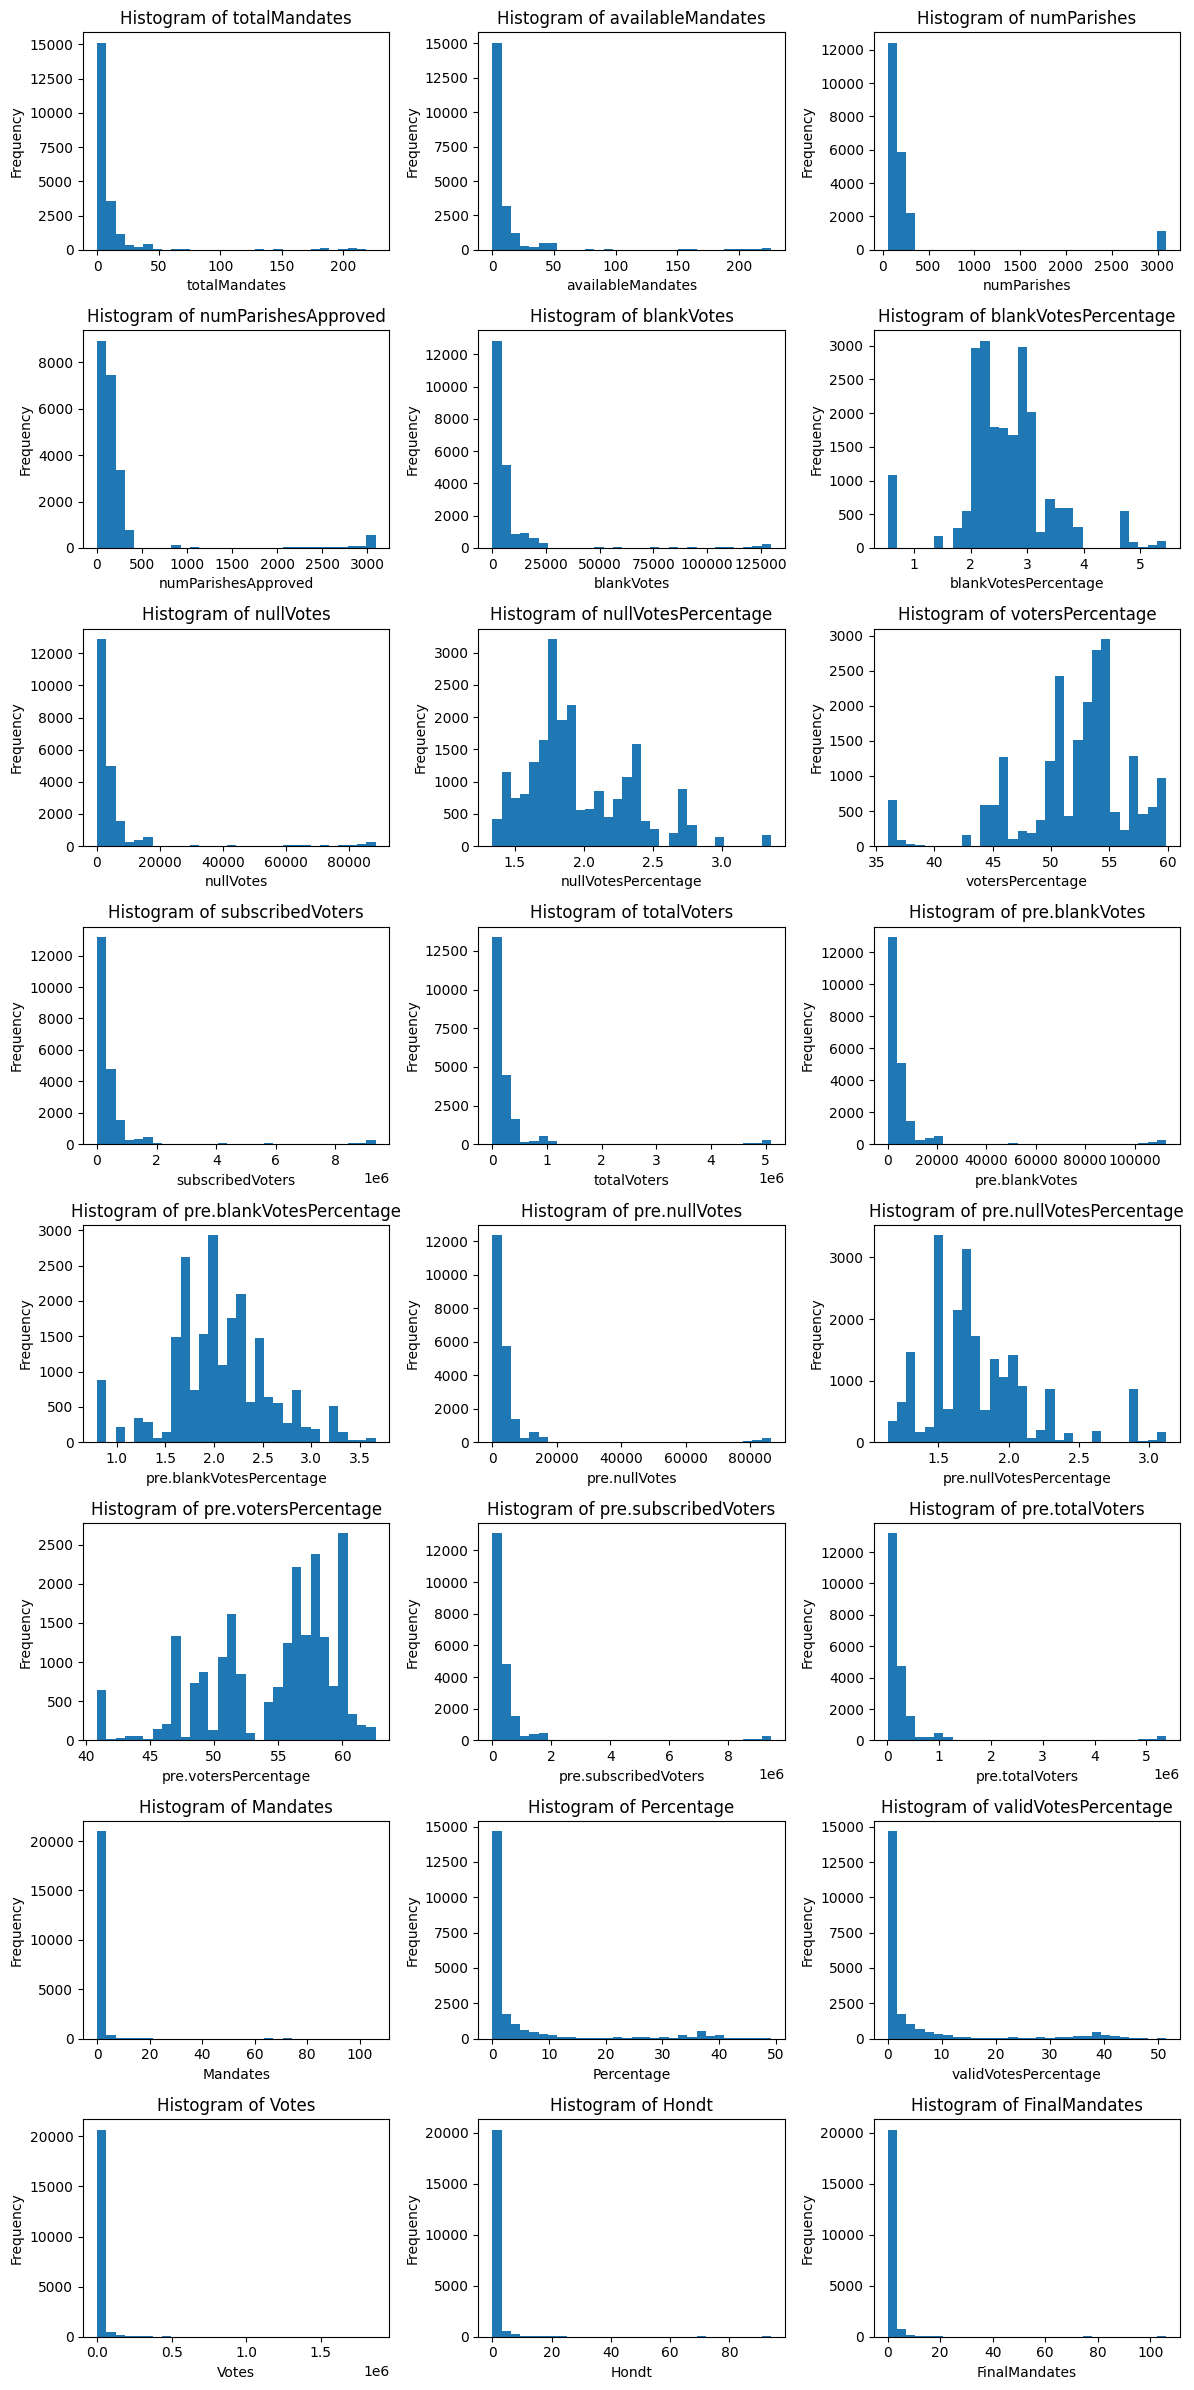

In [16]:
num_features = df_election.select_dtypes(include='number').drop(columns='TimeElapsed')   # Numerical columns ( time elapsed contain too many unq vals)

rows = (len(num_features.columns) + 2) // 3   # Round up so the plots fit into 3 columns

plt.figure(figsize=(4 * 3, 3 * rows))

for i, col in enumerate(num_features):
    plt.subplot(rows, 3, i + 1)
    plt.hist(df_election[col].dropna(), bins=30)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Box-Plots

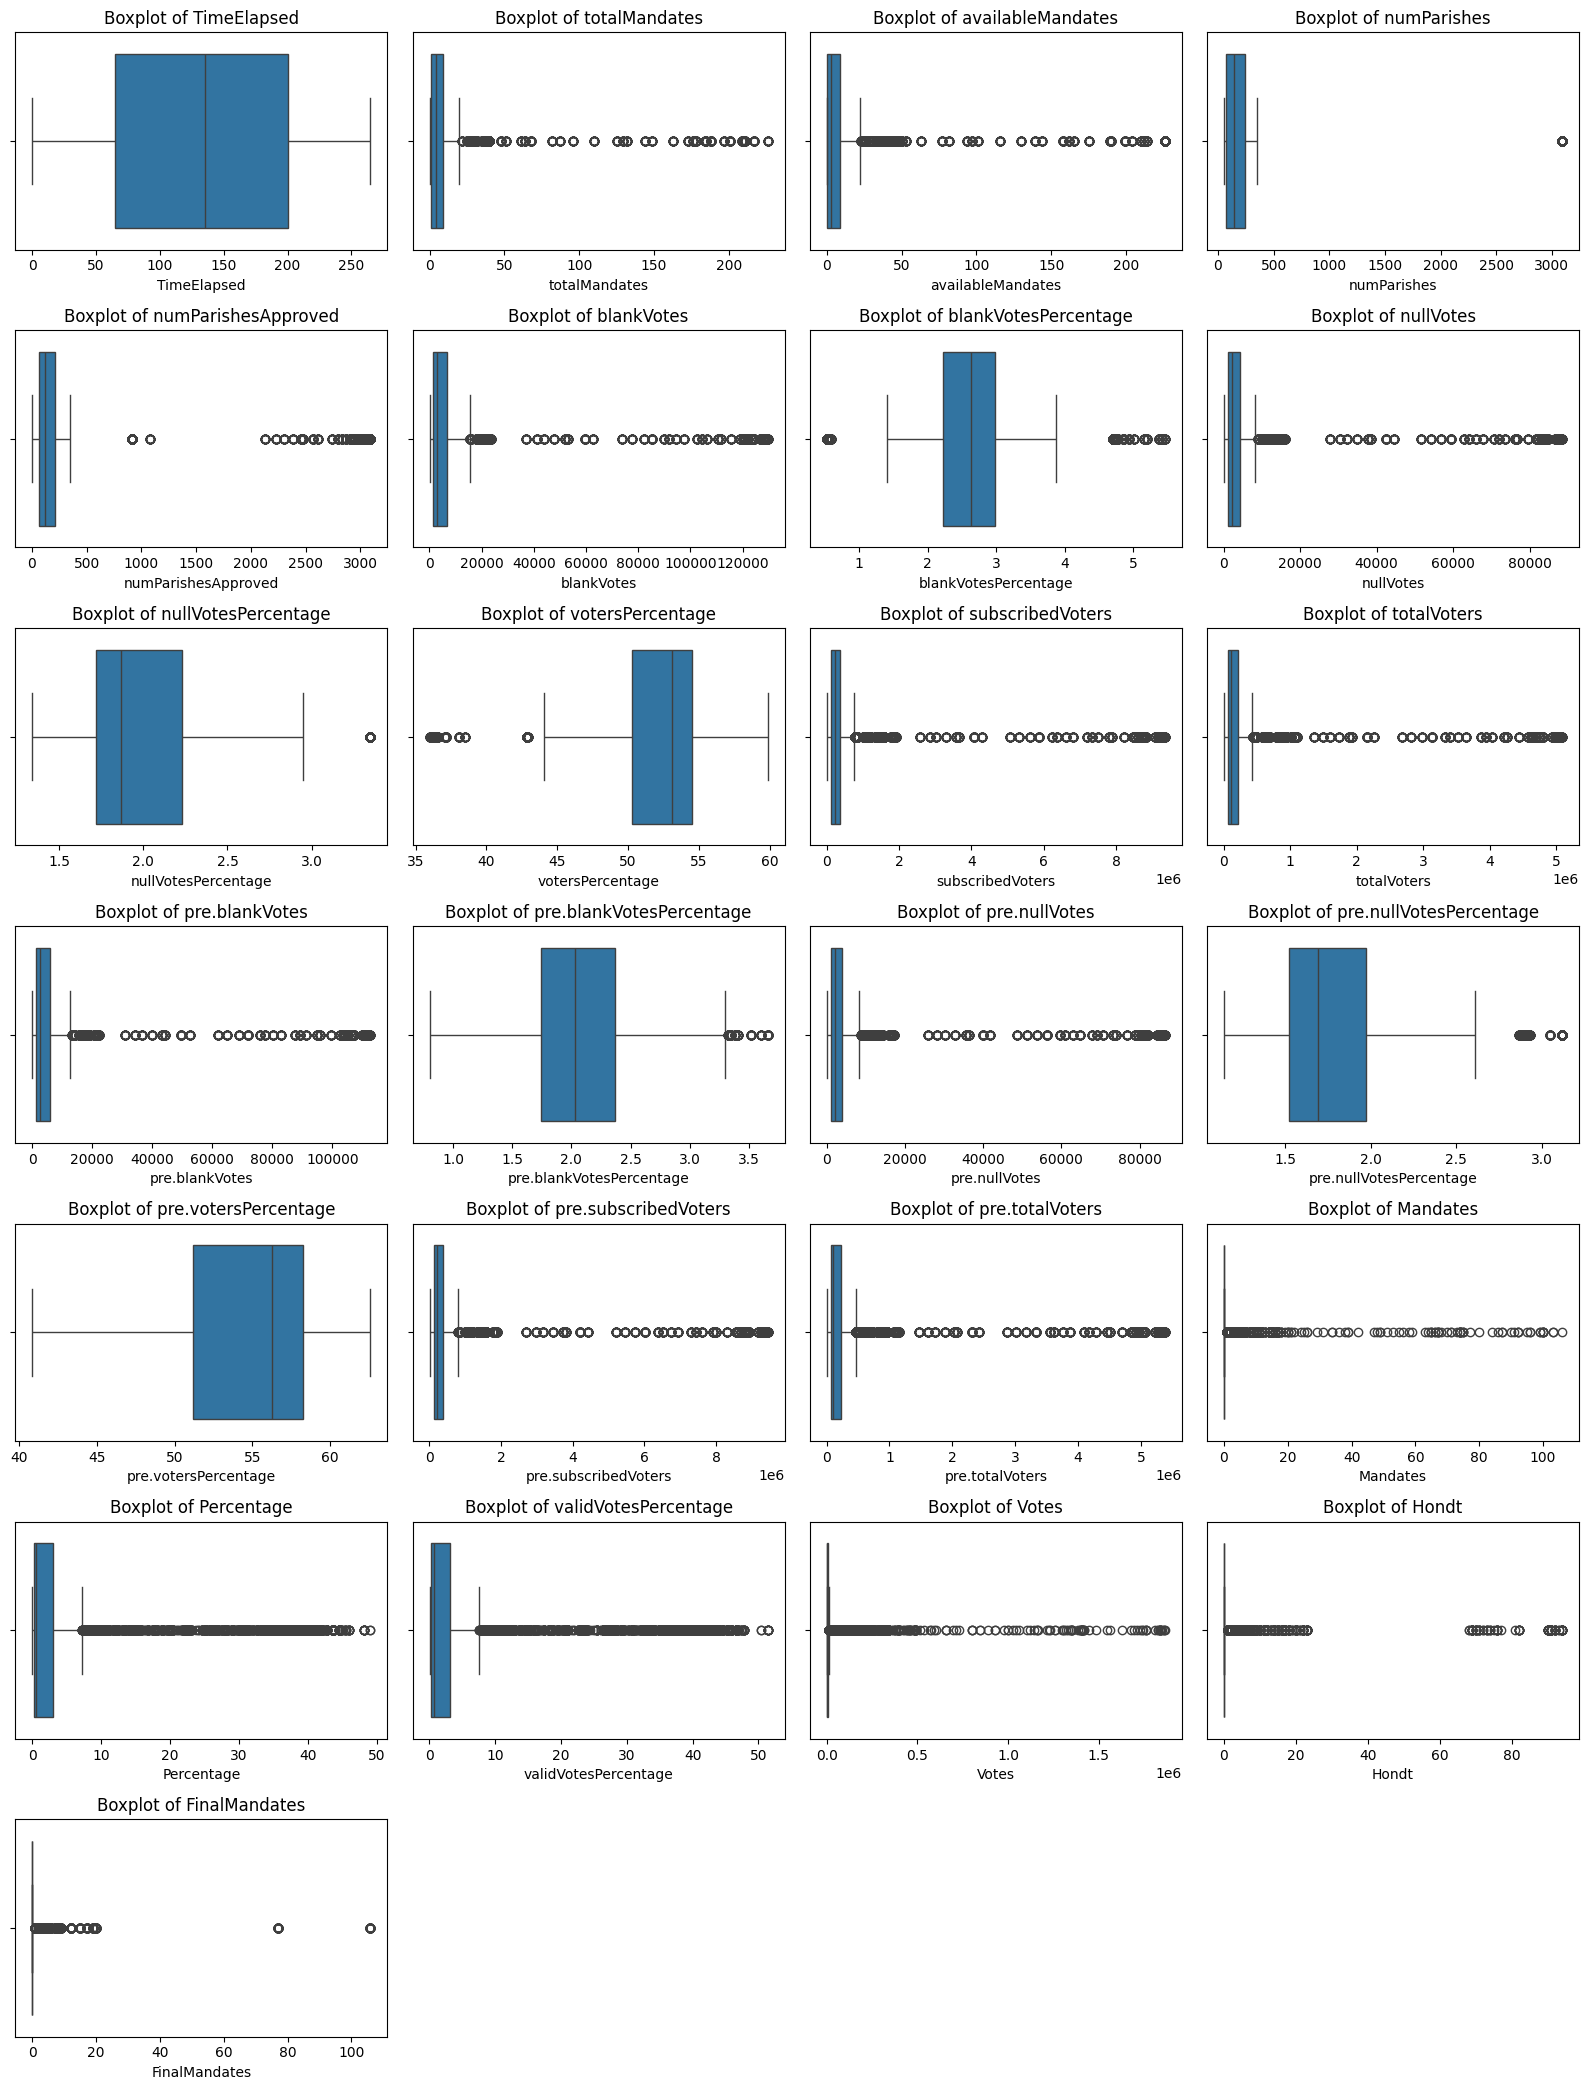

In [17]:
num_cols = df_election.select_dtypes(include=['number']).columns

n_cols = 4 #four plots per row
n_rows = (len(num_cols) +3) // n_cols
plt.figure(figsize=(4 * n_cols, 3 * n_rows))

for i, col in enumerate(num_cols): #enumerate - used for counting
    plt.subplot(n_rows, n_cols, i + 1) #(rows, cols, position)
    sns.boxplot(x=df_election[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

### Scatterplots

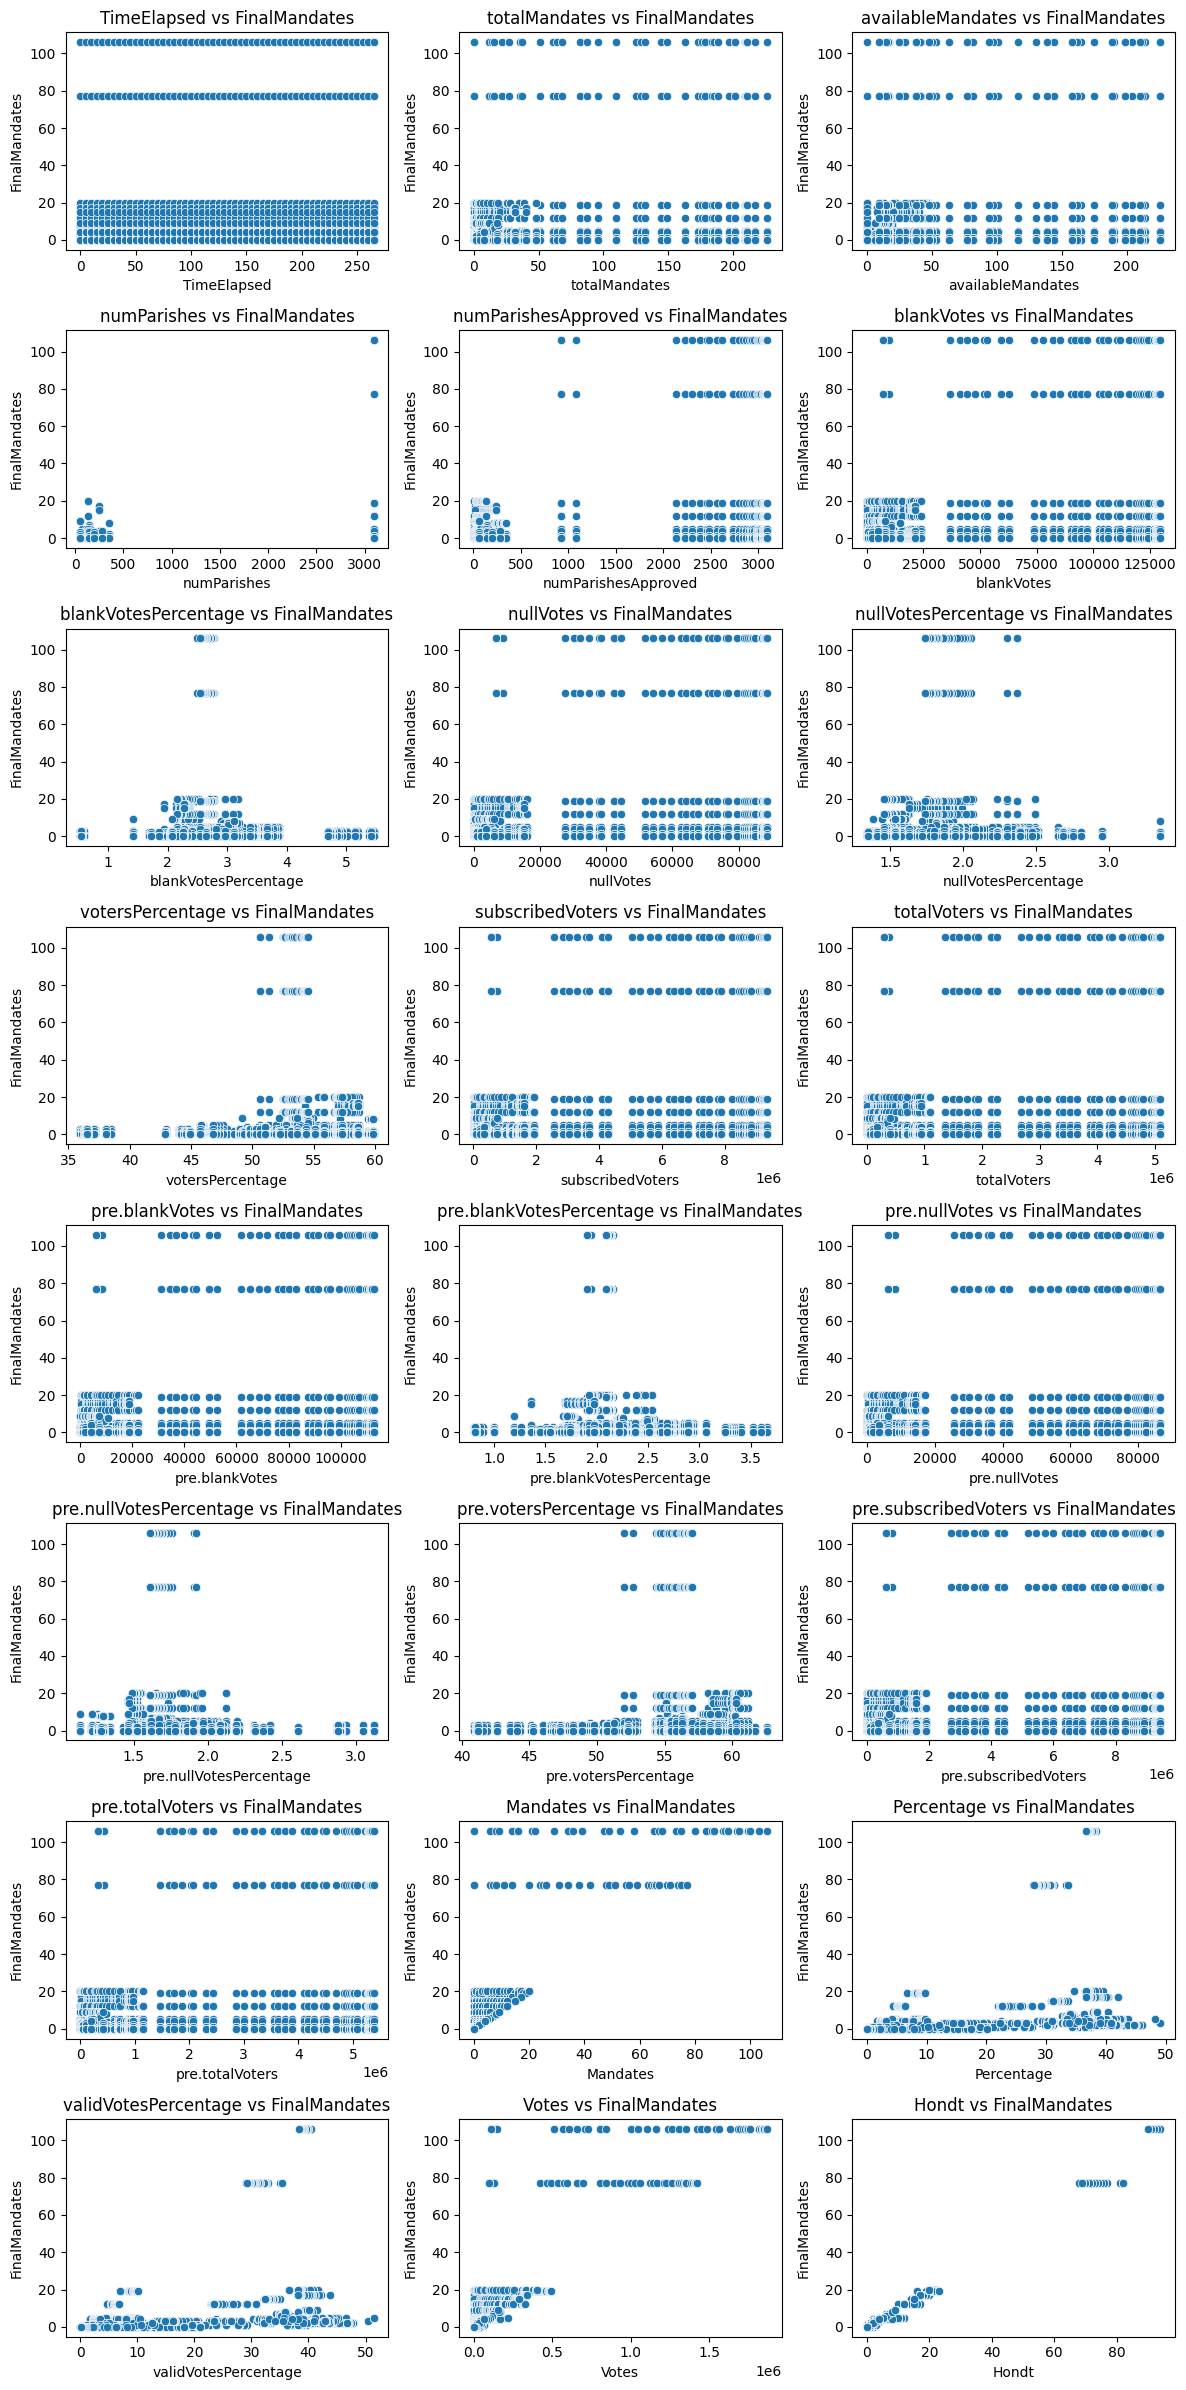

In [18]:
num_features = df_election.select_dtypes(include='number').drop(columns='FinalMandates')  # numerical columns

rows = (len(num_features.columns) + 2) // 3 # +2 added to round up the len(num_features) so its divisible by 3. (integer division)

plt.figure(figsize=(4*3, 3* rows))

for i, col in enumerate(num_features):
    plt.subplot(rows,3,i+1)
    sns.scatterplot(
        x=df_election[col],
        y=df_election['FinalMandates']
    )
    plt.title(f"{col} vs FinalMandates")

plt.tight_layout()
plt.show()

# Data Preprocessing

## Duplicate Removal

In [19]:
# no duplicate Values

## Missing Value Handling

 - Symmetric data - Mean
 - Skewed data - Median
 - Categorical data - Mode

In [20]:
# No missing Values

## Outlier Checking(using Boxplot)

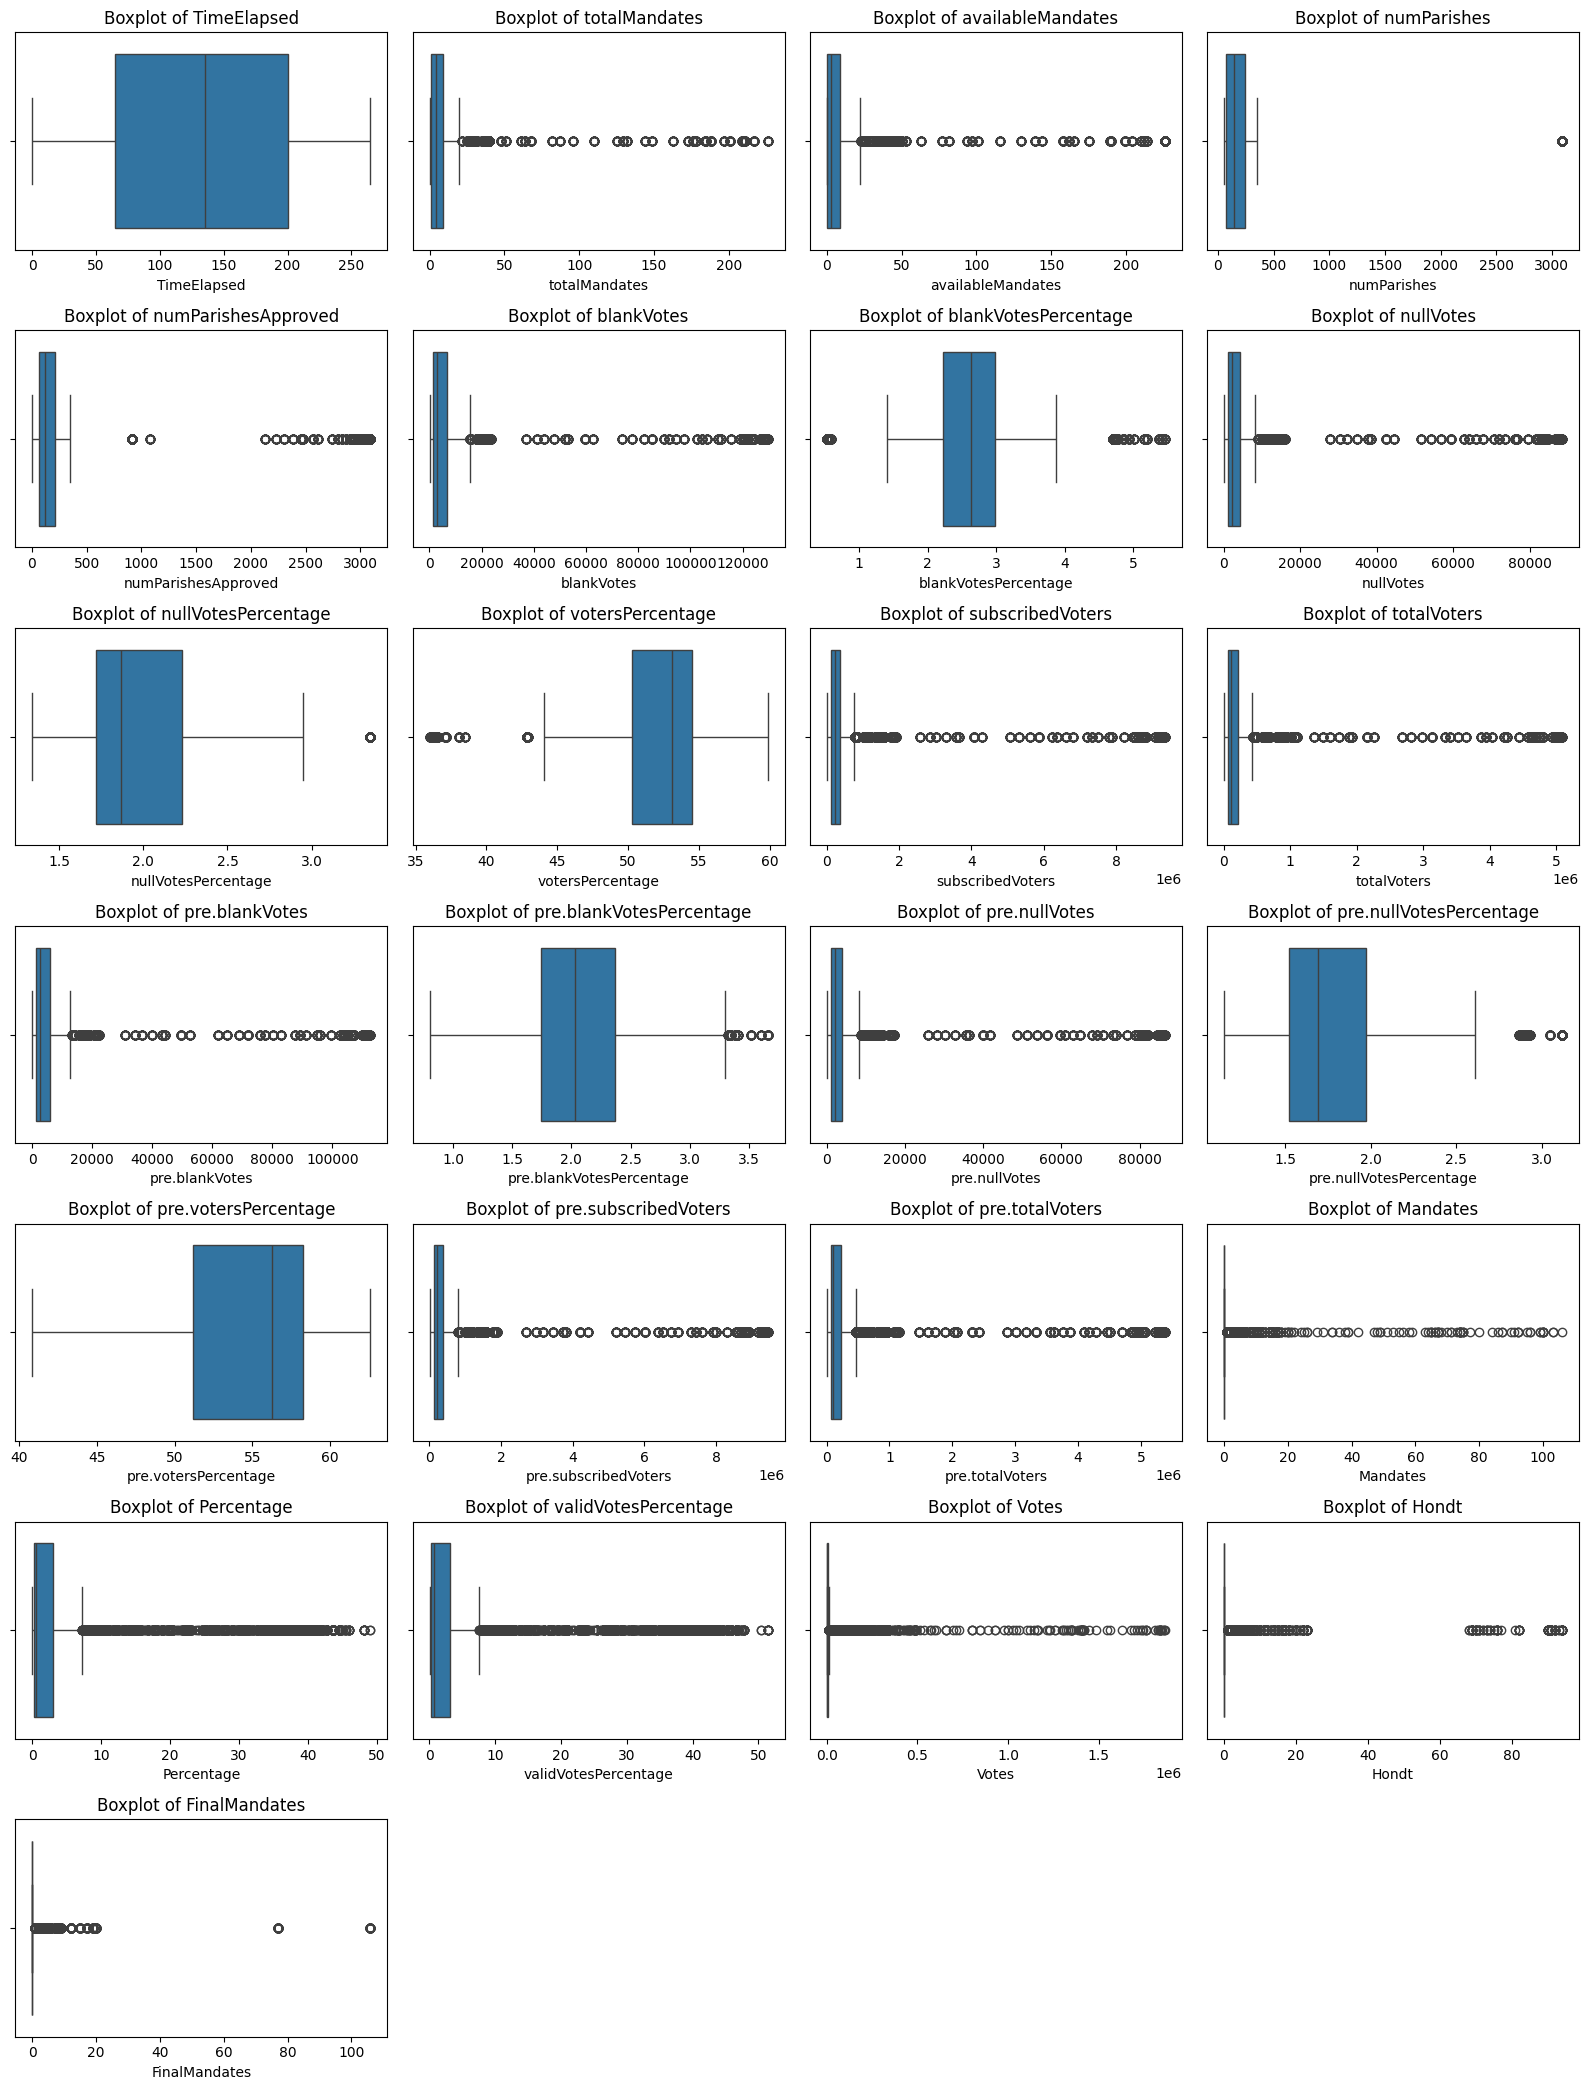

In [21]:
num_cols = df_election.select_dtypes(include=['number']).columns

n_cols = 4 #four plots per row
n_rows = (len(num_cols) +3) // n_cols
plt.figure(figsize=(4 * n_cols, 3 * n_rows))

for i, col in enumerate(num_cols): #enumerate - used for counting
    plt.subplot(n_rows, n_cols, i + 1) #(rows, cols, position)
    sns.boxplot(x=df_election[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

###Outlier Detection(using IQR method)

In [22]:
for col in num_cols:
    Q1 = df_election[col].quantile(0.25)
    Q3 = df_election[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_election[(df_election[col] < lower_bound) | (df_election[col] > upper_bound)]

    print(f"\n{col}")
    print("Number of outliers:", outliers.shape[0])


TimeElapsed
Number of outliers: 0

totalMandates
Number of outliers: 1826

availableMandates
Number of outliers: 2129

numParishes
Number of outliers: 1134

numParishesApproved
Number of outliers: 1134

blankVotes
Number of outliers: 2013

blankVotesPercentage
Number of outliers: 1879

nullVotes
Number of outliers: 2200

nullVotesPercentage
Number of outliers: 168

votersPercentage
Number of outliers: 959

subscribedVoters
Number of outliers: 2744

totalVoters
Number of outliers: 2849

pre.blankVotes
Number of outliers: 2054

pre.blankVotesPercentage
Number of outliers: 221

pre.nullVotes
Number of outliers: 2158

pre.nullVotesPercentage
Number of outliers: 1080

pre.votersPercentage
Number of outliers: 0

pre.subscribedVoters
Number of outliers: 2220

pre.totalVoters
Number of outliers: 2723

Mandates
Number of outliers: 2305

Percentage
Number of outliers: 3434

validVotesPercentage
Number of outliers: 3434

Votes
Number of outliers: 3564

Hondt
Number of outliers: 3889

FinalMandat

###Outlier Removal (by IQR Method)

In [23]:

# df_election[num_cols] = np.clip(df_election[num_cols], lower_bound, upper_bound)


# for this dataset the outlier handling is not necessary because it can be real, here no abnormal values are also not present when taking .describe() so no outlier handling needed.

## Feature Engineering

- Adding new columns, creating new columns from existing one if needed.

### Correlation

In [24]:
# Correlation Matrix
# Correlation measures the linear relationship between
# numerical variables.
#
# Values range from:
# +1 : Perfect Positive Correlation
# -1 : Perfect Negative Correlation
#  0 : No Correlation


# Select only numerical columns
numeric_df = df_election.select_dtypes(include=['int64', 'float64'])

# Calculate correlation matrix
corr_matrix = numeric_df.corr()


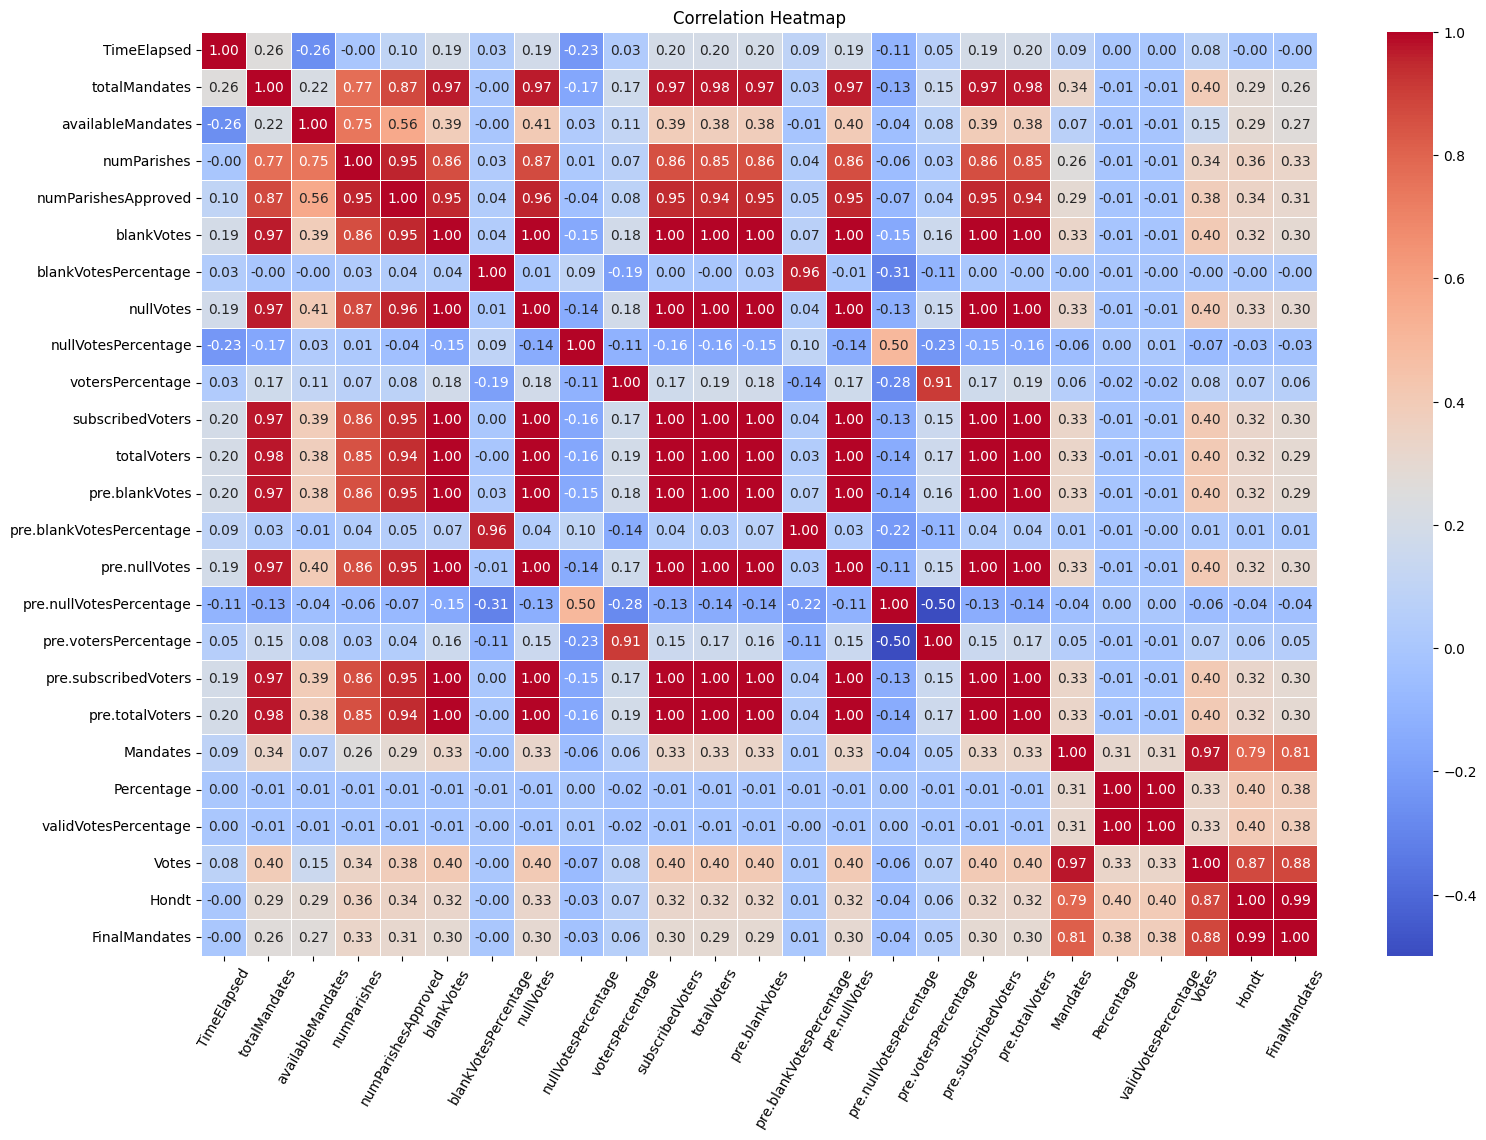

In [25]:
# Correlation Heatmap
# Heatmap provides a visual representation of the
# correlation between numerical features.
#
# Dark Red  -> Strong Positive Correlation
# Dark Blue -> Strong Negative Correlation
# White     -> Weak Correlation

plt.figure(figsize=(18,12))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.xticks(rotation=60)


plt.title("Correlation Heatmap")
plt.show()

### Mutual Information

In [26]:
# Mutual Information
# Mutual Information measures how much information
# a feature provides about the target variable.
#
# Higher MI Score -> More Important Feature
# Lower MI Score  -> Less Important Feature


# Features
X = df_election.drop("FinalMandates", axis=1)

# Keep only numerical columns
X_num = X.select_dtypes(include=['int64','float64'])

# Target
y = df_election["FinalMandates"]

# Calculate MI Score
mi_scores = mutual_info_regression(
    X_num,
    y,
    random_state=42
)

# Create DataFrame
mi_df = pd.DataFrame({
    "Feature": X_num.columns,
    "MI Score": mi_scores
})

# Sort descending
mi_df = mi_df.sort_values(
    by="MI Score",
    ascending=False
)

print(mi_df)

                     Feature  MI Score
23                     Hondt  0.711868
21      validVotesPercentage  0.671200
20                Percentage  0.661556
22                     Votes  0.637251
19                  Mandates  0.339011
3                numParishes  0.190605
16      pre.votersPercentage  0.145730
13  pre.blankVotesPercentage  0.143683
9           votersPercentage  0.140556
11               totalVoters  0.138083
12            pre.blankVotes  0.137887
6       blankVotesPercentage  0.137616
18           pre.totalVoters  0.134827
17      pre.subscribedVoters  0.133851
14             pre.nullVotes  0.133464
10          subscribedVoters  0.130382
5                 blankVotes  0.129800
15   pre.nullVotesPercentage  0.127626
7                  nullVotes  0.123255
4        numParishesApproved  0.122647
8        nullVotesPercentage  0.110668
1              totalMandates  0.071882
2          availableMandates  0.068861
0                TimeElapsed  0.000000


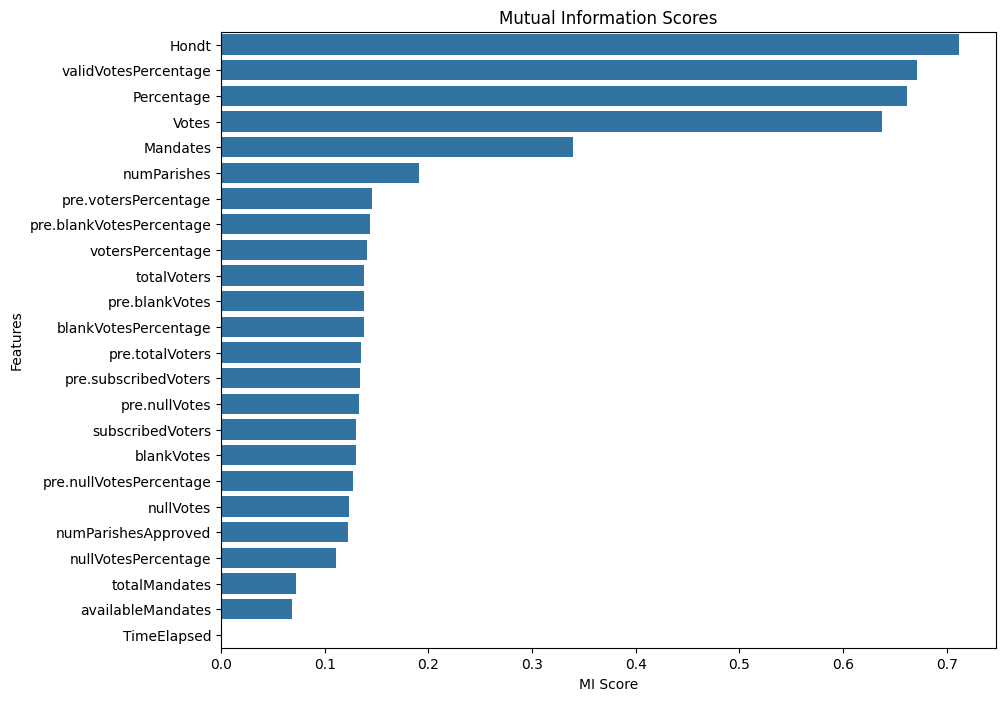

In [27]:
# Mutual Information Visualization

plt.figure(figsize=(10,8))

sns.barplot(
    data=mi_df,
    x="MI Score",
    y="Feature"
)

plt.title("Mutual Information Scores")
plt.xlabel("MI Score")
plt.ylabel("Features")

plt.show()

### Removal of features

In [28]:
# Removing Highly Correlated Features
df_election.drop(columns=['Hondt','Mandates'], inplace=True)

# Removing low correlated and low mutual information features
df_election.drop(columns=['TimeElapsed','blankVotesPercentage','pre.blankVotesPercentage','nullVotesPercentage','pre.nullVotesPercentage'], inplace=True)

# removing feature 'time' - which is almost same for all voters
df_election.drop(columns=['time'], inplace=True)
#'time'can lead to a very large number of features, which might not always be beneficial for model performance.
# most of the dates are same (6,7) and only difference is time and which will not affect the election result.


## Scaling Numerical Columns

- Minmax Scaling if data distribution is skewed
- Standard Scaling if data distribution is symmetric

`note : only do scaling on continuous numerical values`

In [29]:
# Feature Scaling
# Scaling ensures all numerical features have
# similar ranges.
#
# StandardScaler transforms data into:
# Mean = 0
# Standard Deviation = 1
#
# Scaling improves the performance of many
# machine learning algorithms.


# Separate Features and Target
X = df_election.drop("FinalMandates", axis=1)
y = df_election["FinalMandates"]

# Select numerical columns
numeric_columns = X.select_dtypes(
    include=['int64','float64']
).columns

# Create StandardScaler object
scaler = StandardScaler()

# Scale numerical columns
X[numeric_columns] = scaler.fit_transform(
    X[numeric_columns]
)

print("Feature Scaling Completed Successfully.")

# Display first five rows
X.head()

Feature Scaling Completed Successfully.


,territoryName,totalMandates,availableMandates,numParishes,numParishesApproved,blankVotes,nullVotes,votersPercentage,subscribedVoters,totalVoters,pre.blankVotes,pre.nullVotes,pre.votersPercentage,pre.subscribedVoters,pre.totalVoters,Party,Percentage,validVotesPercentage,Votes
0,Território Nacional,-0.36868,6.758472,4.221354,1.405486,0.036163,0.184995,-0.128489,0.081932,0.057204,0.038339,0.158501,-0.380551,0.113892,0.078796,PS,3.210250,3.217832,1.419284
1,Território Nacional,-0.36868,6.758472,4.221354,1.405486,0.036163,0.184995,-0.128489,0.081932,0.057204,0.038339,0.158501,-0.380551,0.113892,0.078796,PPD/PSD,2.727578,2.733495,1.211248
2,Território Nacional,-0.36868,6.758472,4.221354,1.405486,0.036163,0.184995,-0.128489,0.081932,0.057204,0.038339,0.158501,-0.380551,0.113892,0.078796,B.E.,0.177415,0.178549,0.112293
3,Território Nacional,-0.36868,6.758472,4.221354,1.405486,0.036163,0.184995,-0.128489,0.081932,0.057204,0.038339,0.158501,-0.380551,0.113892,0.078796,CDS-PP,-0.006598,-0.006179,0.032984
4,Território Nacional,-0.36868,6.758472,4.221354,1.405486,0.036163,0.184995,-0.128489,0.081932,0.057204,0.038339,0.158501,-0.380551,0.113892,0.078796,PCP-PEV,-0.036464,-0.034669,0.020460


## Encoding Categorical Columns

 - One-hot encoding for all feature columns
 - Label/Ordinal Encoding for target column

 ` note : Try to split target and features before encoding because may accidently do same encoding to target if it is categorical`

In [30]:
ohe = OneHotEncoder(sparse_output=False)

cat_cols = X.select_dtypes(include=['object']).columns
encoded_features = ohe.fit_transform(X[cat_cols])
encoded_df = pd.DataFrame(encoded_features, columns=ohe.get_feature_names_out(cat_cols), index=X.index)

X = X.drop(columns=cat_cols)
X = pd.concat([X, encoded_df], axis=1)

display(X.head())


,totalMandates,availableMandates,numParishes,numParishesApproved,blankVotes,nullVotes,votersPercentage,subscribedVoters,totalVoters,pre.blankVotes,...,Party_PCP-PEV,Party_PCTP/MRPP,Party_PDR,Party_PNR,Party_PPD/PSD,Party_PPM,Party_PS,Party_PTP,Party_PURP,Party_R.I.R.
0,-0.36868,6.758472,4.221354,1.405486,0.036163,0.184995,-0.128489,0.081932,0.057204,0.038339,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,-0.36868,6.758472,4.221354,1.405486,0.036163,0.184995,-0.128489,0.081932,0.057204,0.038339,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,-0.36868,6.758472,4.221354,1.405486,0.036163,0.184995,-0.128489,0.081932,0.057204,0.038339,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.36868,6.758472,4.221354,1.405486,0.036163,0.184995,-0.128489,0.081932,0.057204,0.038339,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.36868,6.758472,4.221354,1.405486,0.036163,0.184995,-0.128489,0.081932,0.057204,0.038339,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Model Building



## KNN Model
- Train Test Split
- Boosting
- Cross Validation

### KNN - Model ( Train Test Split )

In [31]:
# split into train test data
X_train, X_test , y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 33)

In [32]:
kNN = KNeighborsRegressor()
kNN.fit(X_train, y_train)
y_pred_kNN = kNN.predict(X_test)
mse_kNN = mean_squared_error(y_test, y_pred_kNN)
mae_kNN = mean_absolute_error(y_test, y_pred_kNN)
r2_kNN = r2_score(y_test, y_pred_kNN)


### Boosting model

In [33]:

ada_boost_model = AdaBoostRegressor(
    estimator = KNeighborsRegressor(),
    n_estimators = 20,
    learning_rate = 1
)

ada_boost_model.fit(X_train, y_train)
y_pred_boost = ada_boost_model.predict(X_test)
mse_boost_kNN = mean_squared_error(y_test, y_pred_boost)
mae_boost_kNN = mean_absolute_error(y_test, y_pred_boost)
r2_boost_kNN = r2_score(y_test, y_pred_boost)

### Cross-Validation

#### K Fold

In [34]:
kf_obj = KFold(n_splits = 4, shuffle= True, random_state= 33)
scores = cross_val_score(KNeighborsRegressor(), X, y, cv= kf_obj)

#### Grid Search Cross Validation

In [35]:
# Define the parameters to check
param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance']
}

# Build the GridSearchCV object
grid = GridSearchCV(
    KNeighborsRegressor(),
    param_grid,
    cv=4,
    scoring='r2',
    n_jobs=-1
)

# Train the model
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print(f"Best CV Score: {grid.best_score_:.4f}")

# Build the model using the best parameters
knn_model_HPT = KNeighborsRegressor(
    n_neighbors=grid.best_params_['n_neighbors'],
    weights=grid.best_params_['weights']
)

# Train the model
knn_model_HPT.fit(X_train, y_train)

# Make predictions
y_pred_knn_HPT = knn_model_HPT.predict(X_test)

# Evaluate the model
mae_grid_knn = mean_absolute_error(y_test, y_pred_knn_HPT)
mse_grid_knn = mean_squared_error(y_test, y_pred_knn_HPT)
r2_grid_knn = r2_score(y_test, y_pred_knn_HPT)



Best Parameters: {'n_neighbors': 3, 'weights': 'distance'}
Best CV Score: 0.9983


#### Random Search Cross Validation

In [36]:
# Define the parameters to check
param_dist = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

# Build the RandomizedSearchCV object
random_search = RandomizedSearchCV(
    estimator=KNeighborsRegressor(),
    param_distributions=param_dist,
    n_iter=5,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

# Train the model
random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print(f"Best CV Score: {random_search.best_score_:.4f}")

# Build the model using the best parameters
knn_model_RS = KNeighborsRegressor(**random_search.best_params_)

# Train the model
knn_model_RS.fit(X_train, y_train)

# Make predictions
y_pred_knn_RS = knn_model_RS.predict(X_test)

# Evaluate the model
mae_randCV = mean_absolute_error(y_test, y_pred_knn_RS)
mse_randCV = mean_squared_error(y_test, y_pred_knn_RS)
r2_randCV = r2_score(y_test, y_pred_knn_RS)

Best Parameters: {'weights': 'distance', 'p': 1, 'n_neighbors': 3}
Best CV Score: 0.9983


## SVM Model

- Train Test Split
- Ensemble Model
- Cross Validation

### Train Test Split

In [37]:
# split into train test data
X_train, X_test , y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 33)

In [38]:
from sklearn.svm import SVR

# Create SVR model
svr_model = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)

# Train the model
svr_model.fit(X_train, y_train)

# Predict
y_pred_svr = svr_model.predict(X_test)

# Evaluation
mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)
r2_svr = r2_score(y_test, y_pred_svr)

### Bagging

In [66]:
bM_model = BaggingRegressor(SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1))
bM_model.fit(X_train, y_train)
y_pred_bM = bM_model.predict(X_test)

### Cross-Validation


#### K-fold Cross Validation

In [67]:
from sklearn.model_selection import KFold, cross_val_score
kf_obj = KFold(n_splits=3, shuffle=True, random_state=29)
scores_svr = cross_val_score(svr_model , X, y, cv=kf_obj)

####Grid Search Cross Validation

In [68]:
# define parameter to check
param_grid = {
    'C': [100],
    'gamma': ['scale'],
    'kernel': ['rbf'],
    'epsilon': [0.01, 0.1, 0.5]
}

# build grid search object
grid_search = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid,
    cv=kf_obj,
    scoring='r2',
    n_jobs=-1,
    verbose=3
)

#Training the model
grid_search.fit(X_train, y_train)


print("Best parameters:", grid_search.best_params_)
print("Best R² score (CV):", grid_search.best_score_)

# get the best model
best_svr_model = grid_search.best_estimator_

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best parameters: {'C': 100, 'epsilon': 0.01, 'gamma': 'scale', 'kernel': 'rbf'}
Best R² score (CV): 0.9999420553944565


####Random Search Cross Validation

In [75]:
# define parameter grid (same style as your Grid Search, but this is param_distributions)
param_grid = {
    'C': [100],
    'gamma': ['scale'],
    'kernel': ['rbf'],
    'epsilon': [0.01, 0.1, 0.5]
}

# build randomized search object
random_search_svr = RandomizedSearchCV(
    estimator=SVR(),
    param_distributions=param_grid,
    n_iter=5,
    cv=kf_obj,
    scoring='r2',
    n_jobs=4,
    verbose=3,
    random_state=42
)

# run the search
random_search_svr.fit(X_train, y_train)

# best parameters and best score found
print("Best parameters:", random_search_svr.best_params_)
print("Best R² score (CV):", random_search_svr.best_score_)

# get the best model directly
best_svr_model = random_search_svr.best_estimator_

Fitting 3 folds for each of 3 candidates, totalling 9 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 3 is smaller than n_iter=5. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best parameters: {'kernel': 'rbf', 'gamma': 'scale', 'epsilon': 0.01, 'C': 100}
Best R² score (CV): 0.9999420553944565


## Decision Tree Model

- Train Test Split
- Ensemble Model
- Cross Validation

### Train Test Split

In [39]:
# split into train test data
X_train, X_test , y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 33)

In [40]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

mse_dt = mean_squared_error(y_test, y_pred)
mae_dt = mean_absolute_error(y_test, y_pred)
r2_dt = r2_score(y_test, y_pred)

### Bagging - Ensemble model(Random forest)


In [41]:


rf = RandomForestRegressor(random_state=42)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

mse_boost_dt = mean_squared_error(y_test,pred_rf)
mae_boost_dt = mean_absolute_error(y_test,pred_rf)
r2_boost_dt = r2_score(y_test,pred_rf)

### K fold cross validation

In [42]:
#K fold cross validation


kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores_dt = cross_val_score(
    dt,
    X_train,
    y_train,
    cv=kfold,
    scoring='r2'
)

print("Cross Validation Scores:")
print(scores_dt)

print("Average R2 Score:", scores_dt.mean())

Cross Validation Scores:
[0.95657397 0.99862299 0.95688728 0.99990236 0.99965473]
Average R2 Score: 0.9823282673242784


### Grid search


In [43]:

param_grid = {
    'max_depth':[3,5,10,None],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}

grid_dt = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_dt.fit(X_train,y_train)

print("Best Parameters:",grid_dt.best_params_)
print("Best Score:",grid_dt.best_score_)

# Build the model using the best parameters
dt_model = DecisionTreeRegressor(
    max_depth=grid_dt.best_params_['max_depth'],
    min_samples_split=grid_dt.best_params_['min_samples_split'],
    min_samples_leaf=grid_dt.best_params_['min_samples_leaf']
)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions
y_pred_dt_HPT = dt_model.predict(X_test)

# Evaluate the model
mae_grid_dt = mean_absolute_error(y_test, y_pred_dt_HPT)
mse_grid_dt = mean_squared_error(y_test, y_pred_dt_HPT)
r2_grid_dt = r2_score(y_test, y_pred_dt_HPT)


Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best Score: 0.9943340453884224


### Randomized search


In [44]:

random_params = {
    'max_depth':[3,5,10,20,None],
    'min_samples_split':[2,5,10,20],
    'min_samples_leaf':[1,2,4,6],
    'max_features':['sqrt','log2',None]
}

random_search = RandomizedSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_distributions=random_params,
    n_iter=20,
    cv=5,
    random_state=42,
    scoring='r2',
    n_jobs=-1
)

# Train the model
random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print(f"Best CV Score: {random_search.best_score_:.4f}")

# Build the model using the best parameters
dt_model_RS = DecisionTreeRegressor(**random_search.best_params_)

# Train the model
dt_model_RS.fit(X_train, y_train)

# Make predictions
y_pred_dt_RS = dt_model_RS.predict(X_test)

# Evaluate the model
mae_randCV_dt = mean_absolute_error(y_test, y_pred_dt_RS)
mse_randCV_dt = mean_squared_error(y_test, y_pred_dt_RS)
r2_randCV_dt = r2_score(y_test, y_pred_dt_RS)

Best Parameters: {'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': None}
Best CV Score: 0.9821


## Linear Regression Model

- Train Test Split
- Ensemble Model
- Cross Validation

###Linear Regression Model - Train Test Split

In [45]:
# split into train test data
X_train, X_test , y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 33)

In [46]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

###Boosting

In [47]:

ada_boost_model = AdaBoostRegressor(
    estimator = LinearRegression(),
    n_estimators = 20,
    learning_rate = 1
)

ada_boost_model.fit(X_train, y_train)
y_pred_boost = ada_boost_model.predict(X_test)
mse_boost_lr = mean_squared_error(y_test, y_pred_boost)
mae_boost_lr = mean_absolute_error(y_test, y_pred_boost)
r2_boost_lr = r2_score(y_test, y_pred_boost)

### Cross Validation

#### K-fold

In [48]:
kf_obj = KFold(n_splits = 4, shuffle= True, random_state= 33)
scores_lr = cross_val_score(LinearRegression(), X, y, cv= kf_obj)

#### Grid Search Cross Validation

In [49]:
# Define the parameters to check
param_grid = {
    'fit_intercept': [True, False],
    'positive': [True, False]
}

# Build the GridSearchCV object
grid = GridSearchCV(
    LinearRegression(),
    param_grid,
    cv=4,
    scoring='r2',
    n_jobs=-1
)

# Train the model
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print(f"Best CV Score: {grid.best_score_:.4f}")

# Build the model using the best parameters
lr_model_HPT = LinearRegression(
    fit_intercept=grid.best_params_['fit_intercept'],
    positive=grid.best_params_['positive']
)

# Train the model
lr_model_HPT.fit(X_train, y_train)

# Make predictions
y_pred_lr_HPT = lr_model_HPT.predict(X_test)

# Evaluate the model
mae_grid_lr = mean_absolute_error(y_test, y_pred_lr_HPT)
mse_grid_lr = mean_squared_error(y_test, y_pred_lr_HPT)
r2_grid_lr = r2_score(y_test, y_pred_lr_HPT)



Best Parameters: {'fit_intercept': True, 'positive': False}
Best CV Score: 0.8428


#### Random Search Cross Validation

In [50]:
# Define the parameters to check
param_dist = {
    'fit_intercept': [True, False],
    'positive': [True, False]
}

# Build the RandomizedSearchCV object
random_search = RandomizedSearchCV(
    estimator=LinearRegression(),
    param_distributions=param_dist,
    n_iter=5,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

# Train the model
random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print(f"Best CV Score: {random_search.best_score_:.4f}")

# Build the model using the best parameters
lr_model_RS = LinearRegression(**random_search.best_params_)

# Train the model
lr_model_RS.fit(X_train, y_train)

# Make predictions
y_pred_lr_RS = lr_model_RS.predict(X_test)

# Evaluate the model
mae_randCV_lr = mean_absolute_error(y_test, y_pred_lr_RS)
mse_randCV_lr = mean_squared_error(y_test, y_pred_lr_RS)
r2_randCV_lr = r2_score(y_test, y_pred_lr_RS)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=5. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Parameters: {'positive': False, 'fit_intercept': True}
Best CV Score: 0.8413


# Evaluating the model

As we are creating a regression model we use the following metrices:
 - Mean Absolute Error (MAE)
 - Mean Squared Error (MSE)
 - Root Mean Squared Error (RMSE)

## KNN Regressor

In [51]:
print(f'The MSE of the KNN Regression model \t : {mse_kNN}')
print(f'The MAE of the KNN Regression model \t : {mae_kNN}')
print(f'The R2 Score of the KNN Regression model \t : {r2_kNN}')

The MSE of the KNN Regression model 	 : 0.1362993762993762
The MAE of the KNN Regression model 	 : 0.0236082236082236
The R2 Score of the KNN Regression model 	 : 0.9973692125518312


In [52]:
print(f'The MSE of the Boosting KNN Regression model \t : {mse_boost_kNN}')
print(f'The MAE of the Boosting KNN Regression model \t : {mae_boost_kNN}')
print(f'The R2 Score of the Boosting KNN Regression model \t : {r2_boost_kNN}')

The MSE of the Boosting KNN Regression model 	 : 0.00017556017556017556
The MAE of the Boosting KNN Regression model 	 : 0.0007854007854007854
The R2 Score of the Boosting KNN Regression model 	 : 0.9999966114187842


In [53]:
print(' For KNN Regressor -  KFold Crossvalidation')
print(f'Cross validation scores : {(scores*100)}')
print(f'mean of cv scores : {(scores.mean()*100):.2f} %')

 For KNN Regressor -  KFold Crossvalidation
Cross validation scores : [99.75509397 99.962806   99.87812619 99.73995241]
mean of cv scores : 99.83 %


In [54]:
print("\nKNN Regressor (After Hyperparameter Tuning - Grid Search CV)")
print(f"MAE  : {mae_grid_knn:.4f}")
print(f"MSE  : {mse_grid_knn:.4f}")
print(f"R² Score : {r2_grid_knn:.4f}")


KNN Regressor (After Hyperparameter Tuning - Grid Search CV)
MAE  : 0.0023
MSE  : 0.0160
R² Score : 0.9997


In [55]:
print("\nKNN Regressor (Randomized Search CV)")
print(f"MAE       : {mae_randCV:.4f}")
print(f"MSE       : {mse_randCV:.4f}")
print(f"R² Score  : {r2_randCV:.4f}")


KNN Regressor (Randomized Search CV)
MAE       : 0.0088
MSE       : 0.0261
R² Score  : 0.9995


## SVM Regressor

In [71]:
print(f'The MSE of the SVR model \t : {mse_svr}')
print(f'The MAE of the SVR model \t : {mae_svr}')
print(f'The R2 Score of the SVR model \t : {r2_svr}')

The MSE of the SVR model 	 : 0.004317536377388851
The MAE of the SVR model 	 : 0.055133914663817035
The R2 Score of the SVR model 	 : 0.9999166649120704


In [72]:
print("MSE:", mean_squared_error(y_test, y_pred_bM))
print("MAE:", mean_absolute_error(y_test, y_pred_bM))
print("R² score:", r2_score(y_test, y_pred_bM))

MSE: 0.006875200341263799
MAE: 0.05750974807461102
R² score: 0.999867298066561


In [73]:
print("Cross Validation Scores : ",scores_svr)
print("Mean of CV Score : ",scores_svr.mean())

Cross Validation Scores :  [0.99988729 0.99986526 0.99986994]
Mean of CV Score :  0.9998741634947246


In [74]:
print("Best parameters:", grid_search.best_params_)
print("Best R² score (CV):", grid_search.best_score_)

Best parameters: {'C': 100, 'epsilon': 0.01, 'gamma': 'scale', 'kernel': 'rbf'}
Best R² score (CV): 0.9999420553944565


In [76]:
print("Best parameters:", random_search_svr.best_params_)
print("Best R² score (CV):", random_search_svr.best_score_)

Best parameters: {'kernel': 'rbf', 'gamma': 'scale', 'epsilon': 0.01, 'C': 100}
Best R² score (CV): 0.9999420553944565


## Linear Regressor

In [56]:
print(f'The MSE of the Linear Regression model \t : {mse_lr}')
print(f'The MAE of the Linear Regression model \t : {mae_lr}')
print(f'The R2 Score of the Linear Regression model \t : {r2_lr}')

The MSE of the Linear Regression model 	 : 13.706782191289209
The MAE of the Linear Regression model 	 : 0.8314406934594855
The R2 Score of the Linear Regression model 	 : 0.7354380370426339


In [57]:
print(f'The MSE of the Boosting Linear Regression model \t : {mse_boost_lr}')
print(f'The MAE of the Boosting Linear Regression model \t : {mae_boost_lr}')
print(f'The R2 Score of the Boosting Linear Regression model \t : {r2_boost_lr}')

The MSE of the Boosting Linear Regression model 	 : 13.517032798980047
The MAE of the Boosting Linear Regression model 	 : 0.8460568505228387
The R2 Score of the Boosting Linear Regression model 	 : 0.7391004919498974


In [58]:
print(' For Linear Regression -  KFold Crossvalidation')
print(f'Cross validation scores : {(scores_lr*100)}')
print(f'mean of cv scores : {(scores_lr.mean()*100):.2f} %')

 For Linear Regression -  KFold Crossvalidation
Cross validation scores : [75.23908319 82.39451917 86.35098075 83.62803382]
mean of cv scores : 81.90 %


In [59]:
print("\nLinear Regression (After Hyperparameter Tuning - Grid Search CV)")
print(f"MAE  : {mae_grid_lr:.4f}")
print(f"MSE  : {mse_grid_lr:.4f}")
print(f"R² Score : {r2_grid_lr:.4f}")


Linear Regression (After Hyperparameter Tuning - Grid Search CV)
MAE  : 0.8314
MSE  : 13.7068
R² Score : 0.7354


In [60]:
print("\nLinear Regression (Randomized Search CV)")
print(f"MAE       : {mae_randCV_lr:.4f}")
print(f"MSE       : {mse_randCV_lr:.4f}")
print(f"R² Score  : {r2_randCV_lr:.4f}")


Linear Regression (Randomized Search CV)
MAE       : 0.8314
MSE       : 13.7068
R² Score  : 0.7354


## Decision Tree

In [61]:
print(f'The MSE of the DecisionTreeRegressor model \t : {mse_dt}')
print(f'The MAE of the DecisionTreeRegressor model \t : {mae_dt}')
print(f'The R2 Score of the DecisionTreeRegressor model  : {r2_dt}')


The MSE of the DecisionTreeRegressor model 	 : 0.001848001848001848
The MAE of the DecisionTreeRegressor model 	 : 0.001848001848001848
The R2 Score of the DecisionTreeRegressor model  : 0.9999643307240436


In [62]:
print(f'The MSE of the Bagging DecisionTreeRegressor model \t : {mse_boost_dt}')
print(f'The MAE of the Bagging DecisionTreeRegressor model \t : {mae_boost_dt}')
print(f'The R2 Score of the Bagging DecisionTreeRegressor model \t : {r2_boost_dt}')

The MSE of the Bagging DecisionTreeRegressor model 	 : 0.07575188265188265
The MAE of the Bagging DecisionTreeRegressor model 	 : 0.013691383691383698
The R2 Score of the Bagging DecisionTreeRegressor model 	 : 0.9985378722378156


In [63]:
print(' For DecisionTreeRegressor -  KFold Crossvalidation')
print(f'Cross validation scores : {(scores_dt*100)}')
print(f'mean of cv scores : {(scores_dt.mean()*100):.2f} %')

 For DecisionTreeRegressor -  KFold Crossvalidation
Cross validation scores : [95.65739715 99.86229878 95.68872831 99.990236   99.96547342]
mean of cv scores : 98.23 %


In [64]:
print("\nDecisionTreeRegressor (After Hyperparameter Tuning - Grid Search CV)")
print(f"MAE  : {mae_grid_dt:.4f}")
print(f"MSE  : {mse_grid_dt:.4f}")
print(f"R² Score : {r2_grid_dt:.4f}")


DecisionTreeRegressor (After Hyperparameter Tuning - Grid Search CV)
MAE  : 0.0212
MSE  : 0.0160
R² Score : 0.9997


In [65]:
print("\nLinear Regression (Randomized Search CV)")
print(f"MAE       : {mae_randCV_dt:.4f}")
print(f"MSE       : {mse_randCV_dt:.4f}")
print(f"R² Score  : {r2_randCV_dt:.4f}")


Linear Regression (Randomized Search CV)
MAE       : 0.0329
MSE       : 0.4133
R² Score  : 0.9920
